In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

# Imputing Values in CALIFICACION using KDE

In [3]:
def _silverman_bandwidth(x):
    x = np.asarray(x, dtype=float)
    n = len(x)
    if n < 2: return 0.1
    sd = np.std(x, ddof=1)
    q75, q25 = np.percentile(x, [75, 25])
    iqr = q75 - q25
    s = min(sd, iqr/1.34) if iqr > 0 else sd
    h = 0.9 * s * n**(-1/5)
    return max(h, 1e-3)

def _sample_kde_truncated(x_obs, size, low=0.0, high=7.5, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    x_obs = np.asarray(x_obs, dtype=float)
    h = _silverman_bandwidth(x_obs)
    out = np.empty(size, dtype=float); k = 0
    while k < size:
        batch = size - k
        idx = rng.integers(0, len(x_obs), size=batch)
        eps = rng.normal(0.0, h, size=batch)
        draw = x_obs[idx] + eps
        ok = (draw >= low) & (draw <= high)
        take = min(ok.sum(), batch)
        if take:
            out[k:k+take] = draw[ok][:take]
            k += take
    return out

def _sample_empirical(x_obs, size, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    x_obs = np.asarray(x_obs, dtype=float)
    return rng.choice(x_obs, size=size, replace=True)

def impute_nans_from_pre75_kde_df(
    df, value_col='CALIFICACION', out_col='IMPKDE',
    low=0.0, high=7.4, min_kde_n=20, seed=42,
    fallback='uniform',           # 'constant' | 'global' | 'parametric' | 'leave' | 'uniform'
    constant_value=6.5,
    prefer_empirical_if_small=True,
    global_source=None,
    debug=False
):
    rng = np.random.default_rng(seed)
    df = df.copy()

    num = pd.to_numeric(df[value_col], errors='coerce')
    df[out_col] = num
    nan_mask = num.isna()
    need = int(nan_mask.sum())
    if need == 0:
        return df

    obs_pre = num[~num.isna() & (num <= high)]

    def _borrow_pool():
        src = pd.to_numeric(global_source, errors='coerce') if global_source is not None else num
        return src[(~src.isna()) & (src <= high)]

    if len(obs_pre) >= min_kde_n:
        draws = _sample_kde_truncated(obs_pre.values, need, low=low, high=high, rng=rng)
    elif 0 < len(obs_pre) < min_kde_n:
        draws = np.clip(_sample_empirical(obs_pre.values, need, rng=rng), low, high)
    else:
        # No mass in [low, high]; choose fallback
        if fallback == 'global':
            pool = _borrow_pool()
            if len(pool) >= min_kde_n:
                draws = _sample_kde_truncated(pool.values, need, low=low, high=high, rng=rng)
            elif len(pool) > 0:
                draws = np.clip(_sample_empirical(pool.values, need, rng=rng), low, high)
            else:
                draws = np.full(need, min(constant_value, high))
        elif fallback == 'parametric':
            obs_all = num[~num.isna()]
            mu = float(obs_all.mean()) if len(obs_all) else 6.5
            sd = float(obs_all.std(ddof=1)) if len(obs_all) > 1 else 0.5
            sd = max(sd, 1e-3)
            k, draws = 0, np.empty(need)
            while k < need:
                batch = need - k
                cand = rng.normal(mu, sd, size=batch)
                ok = (cand >= low) & (cand <= high)
                take = min(ok.sum(), batch)
                if take:
                    draws[k:k+take] = cand[ok][:take]
                    k += take
        elif fallback == 'uniform':
            # Equally spaced interior points in [low, high]
            # order matches the order of NaNs in the DataFrame
            ks = np.arange(1, need + 1, dtype=float)
            draws = low + (ks / (need + 1.0)) * (high - low)
        elif fallback == 'leave':
            return df
        elif fallback == 'constant':
            draws = np.full(need, min(constant_value, high))
        else:
            raise ValueError("Unknown fallback")

    df.loc[nan_mask, out_col] = draws
    # hard bounds only on imputed entries
    vals = df.loc[nan_mask, out_col].to_numpy(dtype=float, copy=False)
    np.clip(vals, low, high, out=vals)
    df.loc[nan_mask, out_col] = vals
    return df


In [4]:
materias = pd.read_excel('data/onedrive/Archivos2024/Materias estudiantes-profesores 2019-2025 P y O.xlsx')

# clave profesor nunique
profes_ids = materias['CLAVEPROFESOR'].unique()

In [5]:
asesorias = pd.read_excel('data/onedrive/Archivos2024/Asesorias2024.xlsx')

# count how many times each id appears in 'id' column
asesoria_counts = asesorias['id'].value_counts()

# if id in materias['CLAVEALUMNO'] but not in asesoria_counts, assign 0 in materias_counts
asesoria_counts = asesoria_counts.reindex(materias['CLAVEALUMNO'].unique(), fill_value=0)

# if the id of asesorias_counts is in materias['CLAVEALUMNO'], map the count to a new column 'VISITAS' in materias
materias['VISITAS'] = materias['CLAVEALUMNO'].map(asesoria_counts)

# add the timmes each id appears as a new column 'asesoria_count' in asesorias
materias['VISITAS'] = materias['VISITAS'].fillna(0).astype(int)


In [6]:
# make all the classrooms available
salones = {}

# for all the professors
# for all the CLAVEVARIANTEMATERIA in profe_materias
# for all the years
# create a dictionary of salones with keys as (CLAVEPROFESOR, CLAVEVARIANTEMATERIA, anio, CLAVESESION) and values as the corresponding dataframes
for prof_id in profes_ids:
    profe_materias = materias[materias['CLAVEPROFESOR'] == prof_id]
    for materia in profe_materias['CLAVEVARIANTEMATERIA'].unique():
        materia_materias = profe_materias[profe_materias['CLAVEVARIANTEMATERIA'] == materia]
        for anio in materia_materias['anio'].unique():
            anio_materias = materia_materias[materia_materias['anio'] == anio]
            for sesion in anio_materias['CLAVESESION'].unique():
                sesion_materias = anio_materias[anio_materias['CLAVESESION'] == sesion]
                # replace the non numeric calificaciones with the mean of the numeric calificaciones THAT ARE LESS THAN OR EQUAL TO 7.5
                numeric_calificaciones = pd.to_numeric(sesion_materias['CALIFICACION'], errors='coerce')
                mean_calificacion = numeric_calificaciones[numeric_calificaciones <= 7.5].mean()
                sesion_materias['IMPMEAN'] = pd.to_numeric(sesion_materias['CALIFICACION'], errors='coerce').fillna(mean_calificacion)
                mean = sesion_materias['IMPMEAN'].mean()
                std = sesion_materias['IMPMEAN'].std()
                sesion_materias['IMPMEAN_Z'] = (sesion_materias['IMPMEAN'] - mean) / std
                sesion_materias = impute_nans_from_pre75_kde_df(
                    sesion_materias,
                    value_col='CALIFICACION',
                    out_col='IMPKDE', constant_value=6.5, fallback='uniform'
                )
                mean = sesion_materias['IMPKDE'].mean()
                std = sesion_materias['IMPKDE'].std()
                sesion_materias['IMPKDE_Z'] = (sesion_materias['IMPKDE'] - mean) / std
                salones[(prof_id, materia, anio, sesion)] = sesion_materias

ultramerge = pd.concat(salones.values(), ignore_index=True)
# replace them with NaN values
ultramerge['CALIFICACION'] = pd.to_numeric(ultramerge['CALIFICACION'], errors='coerce')

C:\Users\herie\AppData\Local\Temp\ipykernel_34804\1880129717.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sesion_materias['IMPMEAN'] = pd.to_numeric(sesion_materias['CALIFICACION'], errors='coerce').fillna(mean_calificacion)
C:\Users\herie\AppData\Local\Temp\ipykernel_34804\1880129717.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sesion_materias['IMPMEAN_Z'] = (sesion_materias['IMPMEAN'] - mean) / std
C:\Users\herie\AppData\Local\Temp\ipykernel_34804\1880129717.py:19: SettingWithCopyWarning: 

In [7]:
ultramerge

,CLAVEALUMNO,CLAVECARRERA,anio,CLAVESESION,NUMORDEN,CLAVEVARIANTEMATERIA,DESCRIBEMATERIA,CALIFICACION,CLAVEPROFESOR,VISITAS,IMPMEAN,IMPMEAN_Z,IMPKDE,IMPKDE_Z
0,159167,LAR,2019,OTOÑO,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,NaN,22473.0,2,6.216667,-1.077958,6.90,-0.566673
1,165277,LAD,2019,OTOÑO,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,7.6,22473.0,2,7.600000,-0.355548,7.60,-0.252686
2,162781,LII,2019,OTOÑO,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,7.5,22473.0,7,7.500000,-0.407770,7.50,-0.297541
3,161869,LIM,2019,OTOÑO,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,6.9,22473.0,0,6.900000,-0.721105,6.90,-0.566673
4,164732,LMK,2019,OTOÑO,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,NaN,22473.0,0,6.216667,-1.077958,7.00,-0.521818
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26735,183692,LHR,2024,OTOÑO,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,7.8,25510.0,0,7.800000,-1.091103,7.80,-0.274476
26736,183738,LNA,2024,OTOÑO,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,9.6,25510.0,0,9.600000,0.705225,9.60,0.567666
26737,184486,LIS,2024,OTOÑO,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,9.6,25510.0,0,9.600000,0.705225,9.60,0.567666
26738,184591,LMT,2024,OTOÑO,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,10.0,25510.0,0,10.000000,1.104409,10.00,0.754809


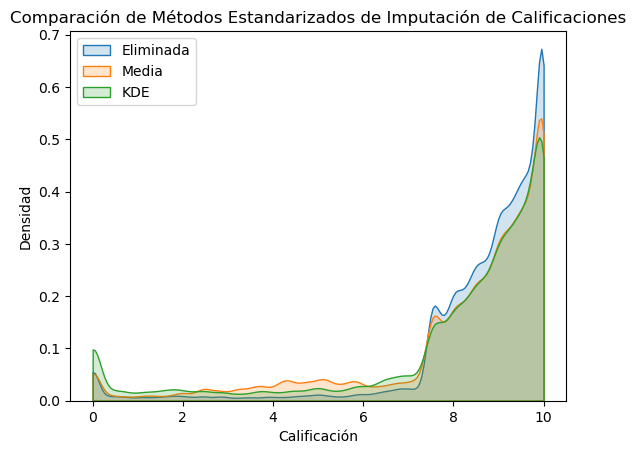

In [8]:
sns.kdeplot(ultramerge['CALIFICACION'], cut=0, bw_adjust=0.5, clip=(0, 10), fill=True, alpha=0.2, label='Eliminada')

sns.kdeplot(ultramerge['IMPMEAN'], cut=0, bw_adjust=0.5, fill=True, alpha=0.2, label='Media')

# z score the IMPKDE column
sns.kdeplot(ultramerge['IMPKDE'], cut=0, bw_adjust=0.5, fill=True, alpha=0.2, label='KDE')

# plot the second subplot: mean imputed z score

plt.title('Comparación de Métodos Estandarizados de Imputación de Calificaciones')
plt.xlabel('Calificación')
plt.ylabel('Densidad')
plt.legend()
plt.savefig('visualizations/profes_distributions/imputation/imputation_comparison_estandarizada.png', bbox_inches='tight')
plt.savefig('visualizations/pdfs/comparacionMetodosImputacionCalificaciones_estandarizada.pdf', bbox_inches='tight')
plt.show()